# 10 — Manual Hyperparameter Tuning for YOLO11n-Seg

## Purpose

This notebook tunes the wheel-fixed `v3` car-parts segmentation baseline using controlled manual experiments. In every stage, one hyperparameter family changes while the dataset, model, seed, image size, batch size, and all unrelated training settings remain fixed.

The tuning covers five stages: optimizer, learning rate, weight decay, augmentation, and learning-rate schedule.

Every stage uses `choose_stage_winner(results_df, tolerance=0.005)` for the final selection.

The selection decision considers both:

- overall validation **Mask mAP50-95**;
- `wheel` validation **Mask mAP50-95** and Recall.

> **Known data limitation:** some wheel annotations may still be missing or merge two wheels into one instance. Missing ground truth can turn a visually correct wheel prediction into a measured false positive; merged instances can affect Precision, Recall, and AP. The wheel metrics and the overall 13-class average are therefore not perfectly clean measurements. This notebook does not modify the dataset.

## Experiment Rules

1. Every trial starts from the same pretrained `yolo11n-seg.pt` weights.
2. Validation is used for tuning; test stays locked until the final model is selected.
3. Short trials are compared only with other short trials from the same stage.
4. The Notebook 09 baseline is compared only with the final 50-epoch tuned model.
5. Each stage writes a CSV checkpoint after every completed trial.
6. Do not change the dataset or class mapping between trials.

## Adapting the Bootcamp Tuning Table to YOLO11n-Seg

| Bootcamp item | Decision in this notebook | Reason |
|---|---|---|
| Optimizer | Tune SGD vs AdamW | Supported and influential |
| Learning rate | Tune around the selected optimizer | One of the most influential settings |
| L2 regularization | Tune `weight_decay` | YOLO training equivalent |
| Epochs | 25 for equal short trials; 50 for final training | Fair comparison with early stopping |
| Batch size | Fix at 8 | Stable on the Kaggle T4 and avoids OOM/confounding |
| Hidden layers / neurons | Do not tune | Would change the YOLO11n architecture |
| Activation / dropout | Do not tune | Architecture-level change; dropout is not a standard segmentation-head tuning control here |
| Augmentation | Tune light/baseline/moderate | Important for segmentation generalization |
| LR schedule | Tune linear vs cosine | YOLO-specific training choice |

The goal is controlled hyperparameter tuning of the same pretrained architecture, not redesigning the network.

## 1. Setup

In [6]:
%pip install -q ultralytics==8.4.138

Note: you may need to restart the kernel to use updated packages.


In [7]:
from pathlib import Path
from shutil import copy2
import gc
import json

import matplotlib.pyplot as plt
import pandas as pd
import torch
import yaml
from ultralytics import YOLO

pd.set_option("display.max_columns", None)

In [8]:
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if not torch.cuda.is_available():
    raise RuntimeError("GPU is not available. Enable a Kaggle GPU before training.")

print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


## 2. Dataset and Output Paths

In [9]:
DATASET_INPUT_DIR = Path(
    "/kaggle/input/datasets/haifafd/car-parts-wheel-fixed-v3"
)

yaml_candidates = list(DATASET_INPUT_DIR.rglob("corrected-carparts.yaml"))
if len(yaml_candidates) != 1:
    raise FileNotFoundError(
        f"Expected one corrected-carparts.yaml, found {len(yaml_candidates)}: "
        f"{yaml_candidates}"
    )

SOURCE_YAML = yaml_candidates[0]
DATASET_DIR = SOURCE_YAML.parent
DATASET_YAML = Path("/kaggle/working/corrected-carparts-tuning.yaml")

RUNS_DIR = Path("/kaggle/working/qaddir-training-results")
TUNING_DIR = Path("/kaggle/working/qaddir-manual-tuning")
RUNS_DIR.mkdir(parents=True, exist_ok=True)
TUNING_DIR.mkdir(parents=True, exist_ok=True)

print("Dataset root:", DATASET_DIR)
print("Source YAML:", SOURCE_YAML)
print("Tuning output:", TUNING_DIR)

Dataset root: /kaggle/input/datasets/haifafd/car-parts-wheel-fixed-v3/carparts-corrected-expanded-v3
Source YAML: /kaggle/input/datasets/haifafd/car-parts-wheel-fixed-v3/carparts-corrected-expanded-v3/corrected-carparts.yaml
Tuning output: /kaggle/working/qaddir-manual-tuning


In [10]:
with open(SOURCE_YAML, encoding="utf-8") as file:
    data_config = yaml.safe_load(file)

data_config["path"] = str(DATASET_DIR)
data_config["train"] = "images/train"
data_config["val"] = "images/val"
data_config["test"] = "images/test"

with open(DATASET_YAML, "w", encoding="utf-8") as file:
    yaml.safe_dump(data_config, file, sort_keys=False, allow_unicode=True)

raw_names = data_config["names"]
if isinstance(raw_names, dict):
    class_names = [
        raw_names[index]
        for index in sorted(raw_names, key=lambda value: int(value))
    ]
else:
    class_names = list(raw_names)

if "wheel" not in class_names:
    raise ValueError(f"wheel is missing from the class list: {class_names}")

WHEEL_CLASS_ID = class_names.index("wheel")

print("Number of classes:", len(class_names))
print("Wheel class ID:", WHEEL_CLASS_ID)
print("Classes:", class_names)

Number of classes: 13
Wheel class ID: 12
Classes: ['back_bumper', 'back_door', 'back_glass', 'back_light', 'front_bumper', 'front_door', 'front_glass', 'front_light', 'hood', 'side_mirror', 'trunk_or_tailgate', 'truck_bed', 'wheel']


## 3. Notebook 09 Baseline Reference

In [11]:
BASELINE_METRICS = {
    "overall_mask_map50": 0.935,
    "overall_mask_map50_95": 0.737,
    "wheel_mask_precision": 0.833,
    "wheel_mask_recall": 0.761,
    "wheel_mask_map50": 0.878,
    "wheel_mask_map50_95": 0.618,
}

display(pd.DataFrame({
    "Metric": list(BASELINE_METRICS),
    "Notebook 09 baseline": list(BASELINE_METRICS.values()),
}))

,Metric,Notebook 09 baseline
0,overall_mask_map50,0.935
1,overall_mask_map50_95,0.737
2,wheel_mask_precision,0.833
3,wheel_mask_recall,0.761
4,wheel_mask_map50,0.878
5,wheel_mask_map50_95,0.618


## 4. Fixed Trial Settings

These settings are passed explicitly to **every** short trial. `optimizer="SGD"` is fixed so that Ultralytics does not ignore the learning-rate candidates through `optimizer="auto"`.

The first learning-rate stage includes `lr0=0.01` as its short-trial control. This control is not compared directly with the 50-epoch Notebook 09 result.

In [12]:
TRIAL_EPOCHS = 25
TRIAL_PATIENCE = 8

FIXED_SETTINGS = {
    "optimizer": "SGD",
    "lrf": 0.01,
    "momentum": 0.937,
    "weight_decay": 0.0005,
    "cos_lr": False,

    "hsv_h": 0.01,
    "hsv_s": 0.30,
    "hsv_v": 0.30,
    "degrees": 10.0,
    "translate": 0.05,
    "scale": 0.15,
    "shear": 0.0,
    "perspective": 0.0,
    "flipud": 0.0,
    "fliplr": 0.5,
    "mosaic": 0.20,
    "mixup": 0.0,
    "copy_paste": 0.0,
    "close_mosaic": 10,

    "imgsz": 640,
    "batch": 8,
    "workers": 2,
    "device": 0,
    "seed": 42,
    "deterministic": True,
    "amp": True,
    "cache": False,
}

display(pd.DataFrame(
    FIXED_SETTINGS.items(), columns=["Fixed setting", "Value"]
))

,Fixed setting,Value
0,optimizer,SGD
1,lrf,0.01
2,momentum,0.937
3,weight_decay,0.0005
4,cos_lr,False
5,hsv_h,0.01
6,hsv_s,0.3
7,hsv_v,0.3
8,degrees,10.0
9,translate,0.05


## 5. Reusable Trial Functions

In [13]:
def extract_validation_metrics(validation_result, wheel_class_id):
    """Extract overall mask metrics and wheel-specific mask metrics."""
    seg = validation_result.seg

    return {
        "overall_mask_precision": float(seg.mp),
        "overall_mask_recall": float(seg.mr),
        "overall_mask_map50": float(seg.map50),
        "overall_mask_map50_95": float(seg.map),
        "wheel_mask_precision": float(seg.p[wheel_class_id]),
        "wheel_mask_recall": float(seg.r[wheel_class_id]),
        "wheel_mask_map50": float(seg.ap50[wheel_class_id]),
        "wheel_mask_map50_95": float(seg.ap[wheel_class_id]),
    }


def clear_gpu():
    gc.collect()
    torch.cuda.empty_cache()

In [14]:
def run_trial_stage(stage_name, candidates, base_settings):
    """
    Run one controlled tuning stage.

    candidates must be a list of dictionaries with:
    - name: unique trial name
    - overrides: settings changed in this stage only
    """
    stage_dir = TUNING_DIR / stage_name
    stage_dir.mkdir(parents=True, exist_ok=True)
    records = []

    for candidate in candidates:
        trial_name = candidate["name"]
        overrides = candidate["overrides"]
        settings = {**base_settings, **overrides}

        print(f"\n{'=' * 70}")
        print("Stage:", stage_name)
        print("Trial:", trial_name)
        print("Changed values:", overrides)

        model = YOLO("yolo11n-seg.pt")
        model.train(
            data=str(DATASET_YAML),
            epochs=TRIAL_EPOCHS,
            patience=TRIAL_PATIENCE,
            project=str(stage_dir),
            name=trial_name,
            save=True,
            save_period=-1,
            plots=False,
            verbose=False,
            exist_ok=True,
            **settings,
        )

        run_dir = Path(model.trainer.save_dir)
        best_path = run_dir / "weights" / "best.pt"
        if not best_path.exists():
            raise FileNotFoundError(f"Best checkpoint not found: {best_path}")

        best_trial_model = YOLO(str(best_path))
        val_result = best_trial_model.val(
            data=str(DATASET_YAML),
            split="val",
            imgsz=settings["imgsz"],
            batch=settings["batch"],
            device=settings["device"],
            workers=settings["workers"],
            project=str(stage_dir),
            name=f"{trial_name}_validation",
            plots=False,
            verbose=False,
            exist_ok=True,
        )

        record = {
            "stage": stage_name,
            "trial": trial_name,
            "changed_values": json.dumps(overrides, sort_keys=True),
            "best_model_path": str(best_path),
            **extract_validation_metrics(val_result, WHEEL_CLASS_ID),
        }
        records.append(record)

        checkpoint_df = pd.DataFrame(records)
        checkpoint_df.to_csv(stage_dir / "stage_results.csv", index=False)

        print(
            "Overall Mask mAP50-95:",
            round(record["overall_mask_map50_95"], 4),
        )
        print(
            "Wheel Mask mAP50-95:",
            round(record["wheel_mask_map50_95"], 4),
        )

        del model, best_trial_model, val_result
        clear_gpu()

    return pd.DataFrame(records).sort_values(
        [
            "overall_mask_map50_95",
            "wheel_mask_map50_95",
            "wheel_mask_recall",
        ],
        ascending=False,
    ).reset_index(drop=True)


def plot_stage_results(results_df, title):
    chart_df = results_df.sort_values("overall_mask_map50_95")
    x = range(len(chart_df))

    fig, axis = plt.subplots(figsize=(10, 5))
    axis.bar(
        [index - 0.18 for index in x],
        chart_df["overall_mask_map50_95"],
        width=0.36,
        label="Overall Mask mAP50-95",
    )
    axis.bar(
        [index + 0.18 for index in x],
        chart_df["wheel_mask_map50_95"],
        width=0.36,
        label="Wheel Mask mAP50-95",
    )
    axis.set_xticks(list(x), chart_df["trial"], rotation=15)
    axis.set_ylim(0, 1)
    axis.set_title(title)
    axis.set_ylabel("Metric")
    axis.grid(alpha=0.25, axis="y")
    axis.legend()
    plt.tight_layout()
    plt.show()

def choose_stage_winner(results_df, tolerance=0.005):
    """Select by overall Mask mAP50-95, then wheel metrics within tolerance."""
    best_overall = results_df["overall_mask_map50_95"].max()

    close_candidates = results_df[
        results_df["overall_mask_map50_95"] >= best_overall - tolerance
    ].copy()

    close_candidates = close_candidates.sort_values(
        [
            "wheel_mask_map50_95",
            "wheel_mask_recall",
            "overall_mask_map50_95",
        ],
        ascending=False,
    )

    return close_candidates.iloc[0], close_candidates

## 6. Stage 1 — Optimizer Configuration

This first stage compares SGD and AdamW. Each optimizer uses an appropriate reference learning rate because the same numeric learning rate is not directly comparable across optimizer families. This is intentionally treated as a **configuration comparison**, not as a claim that only one scalar changed.

In [15]:
optimizer_candidates = [
    {
        "name": "optimizer_sgd",
        "overrides": {
            "optimizer": "SGD",
            "lr0": 0.01,
            "momentum": 0.937,
        },
    },
    {
        "name": "optimizer_adamw",
        "overrides": {
            "optimizer": "AdamW",
            "lr0": 0.001,
            "momentum": 0.90,
        },
    },
]

display(pd.DataFrame([
    {"Trial": item["name"], **item["overrides"]}
    for item in optimizer_candidates
]))

,Trial,optimizer,lr0,momentum
0,optimizer_sgd,SGD,0.010,0.937
1,optimizer_adamw,AdamW,0.001,0.900


,trial,overall_mask_map50_95,wheel_mask_precision,wheel_mask_recall,wheel_mask_map50_95
0,optimizer_adamw,0.724411,0.864322,0.677712,0.576200
1,optimizer_sgd,0.717369,0.779712,0.715442,0.570833


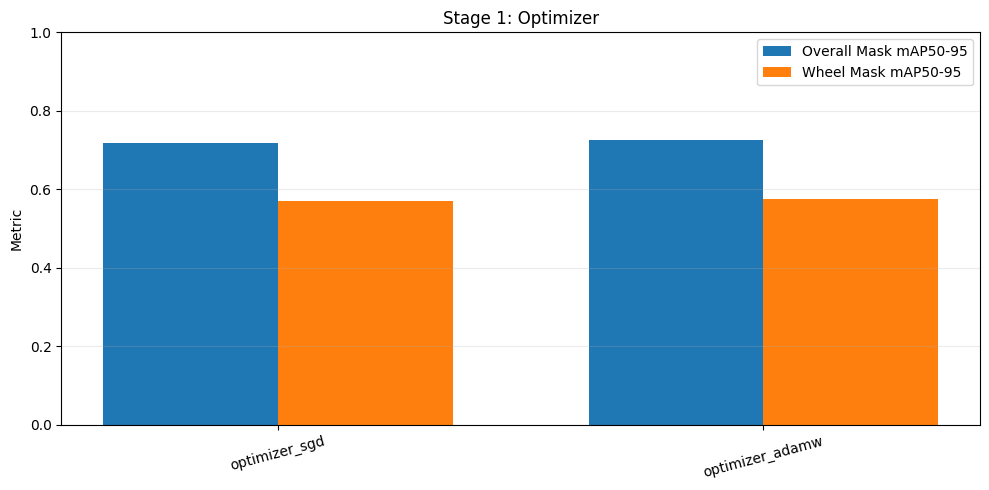

In [16]:
optimizer_results_df = run_trial_stage(
    stage_name="01_optimizer",
    candidates=optimizer_candidates,
    base_settings=FIXED_SETTINGS,
)

display(optimizer_results_df[[
    "trial",
    "overall_mask_map50_95",
    "wheel_mask_precision",
    "wheel_mask_recall",
    "wheel_mask_map50_95",
]])

plot_stage_results(optimizer_results_df, "Stage 1: Optimizer")

In [17]:
optimizer_winner, optimizer_finalists = choose_stage_winner(
    optimizer_results_df, tolerance=0.005
)

display(optimizer_finalists[[
    "trial",
    "overall_mask_map50_95",
    "wheel_mask_map50_95",
    "wheel_mask_recall",
]])

BEST_OPTIMIZER_TRIAL = optimizer_winner["trial"]
BEST_OPTIMIZER_CONFIG = next(
    candidate["overrides"]
    for candidate in optimizer_candidates
    if candidate["name"] == BEST_OPTIMIZER_TRIAL
)

BEST_OPTIMIZER = BEST_OPTIMIZER_CONFIG["optimizer"]
REFERENCE_LR = BEST_OPTIMIZER_CONFIG["lr0"]
BEST_MOMENTUM = BEST_OPTIMIZER_CONFIG["momentum"]

print("Selected optimizer trial:", BEST_OPTIMIZER_TRIAL)
display(pd.DataFrame(
    BEST_OPTIMIZER_CONFIG.items(), columns=["Setting", "Value"]
))

,trial,overall_mask_map50_95,wheel_mask_map50_95,wheel_mask_recall
0,optimizer_adamw,0.724411,0.5762,0.677712


Selected optimizer trial: optimizer_adamw


,Setting,Value
0,optimizer,AdamW
1,lr0,0.001
2,momentum,0.9


## 7. Stage 2 — Learning Rate

The selected optimizer is fixed. Only `lr0` changes to half, equal to, or twice that optimizer's reference value.

The following cell is the single authoritative Learning Rate execution cell. Its retained table records the three successfully completed trials.

In [18]:
learning_rate_values = [
    REFERENCE_LR * 0.5,
    REFERENCE_LR,
    REFERENCE_LR * 2.0,
]

lr_candidates = [
    {
        "name": f"lr_{value:.6f}".replace(".", "_"),
        "overrides": {"lr0": value},
    }
    for value in learning_rate_values
]

display(pd.DataFrame({
    "Trial": [candidate["name"] for candidate in lr_candidates],
    "Optimizer (fixed)": BEST_OPTIMIZER,
    "lr0": learning_rate_values,
}))

,Trial,Optimizer (fixed),lr0
0,lr_0_000500,AdamW,0.0005
1,lr_0_001000,AdamW,0.0010
2,lr_0_002000,AdamW,0.0020


In [27]:
settings_after_optimizer = {
    **FIXED_SETTINGS,
    "optimizer": BEST_OPTIMIZER,
    "momentum": BEST_MOMENTUM,
}

lr_results_df = run_trial_stage(
    stage_name="02_learning_rate",
    candidates=lr_candidates,
    base_settings=settings_after_optimizer,
)

display(lr_results_df[[
    "trial",
    "overall_mask_map50_95",
    "wheel_mask_precision",
    "wheel_mask_recall",
    "wheel_mask_map50_95",
]])

plot_stage_results(lr_results_df, "Stage 2: Learning Rate")

### Recorded Learning Rate Results

The following values document the three successfully completed Learning Rate trials. No experiment was rerun during notebook cleanup.

| Trial | Overall Mask mAP50-95 | Wheel Mask mAP50-95 | Wheel Mask Recall |
|---|---:|---:|---:|
| `lr_0_000500` | 0.719685 | 0.571977 | 0.696809 |
| `lr_0_001000` | 0.724411 | 0.576200 | 0.677712 |
| `lr_0_002000` | 0.711739 | 0.561008 | 0.686170 |

In [26]:
lr_winner, lr_finalists = choose_stage_winner(lr_results_df, tolerance=0.005)

print("Candidates within 0.005 of best overall result:")

display(lr_finalists[[
    "trial",
    "overall_mask_map50_95",
    "wheel_mask_map50_95",
    "wheel_mask_recall",
]])

BEST_LR_TRIAL = lr_winner["trial"]

BEST_LR = next(
    candidate["overrides"]["lr0"]
    for candidate in lr_candidates
    if candidate["name"] == BEST_LR_TRIAL
)

print("Selected learning-rate trial:", BEST_LR_TRIAL)
print("Selected lr0:", BEST_LR)

Candidates within 0.005 of best overall result:


,trial,overall_mask_map50_95,wheel_mask_map50_95,wheel_mask_recall
1,lr_0_001000,0.724411,0.576200,0.677712
0,lr_0_000500,0.719685,0.571977,0.696809


Selected learning-rate trial: lr_0_001000
Selected lr0: 0.001


In [29]:
settings_after_optimizer = {
    **FIXED_SETTINGS,
    "optimizer": BEST_OPTIMIZER,
    "momentum": BEST_MOMENTUM,
}

settings_after_lr = {
    **settings_after_optimizer,
    "lr0": BEST_LR,
}

print("Optimizer:", BEST_OPTIMIZER)
print("Momentum:", BEST_MOMENTUM)
print("Learning rate:", BEST_LR)

Optimizer: AdamW
Momentum: 0.9
Learning rate: 0.001


## 8. Stage 3 — Weight Decay

The optimizer and learning rate are fixed. Only regularization through `weight_decay` changes.

In [30]:
weight_decay_values = [0.0001, 0.0005, 0.001]

weight_decay_candidates = [
    {
        "name": f"weight_decay_{value:.4f}".replace(".", "_"),
        "overrides": {"weight_decay": value},
    }
    for value in weight_decay_values
]

display(pd.DataFrame({
    "Trial": [item["name"] for item in weight_decay_candidates],
    "weight_decay": weight_decay_values,
}))

,Trial,weight_decay
0,weight_decay_0_0001,0.0001
1,weight_decay_0_0005,0.0005
2,weight_decay_0_0010,0.0010


,trial,overall_mask_map50_95,wheel_mask_precision,wheel_mask_recall,wheel_mask_map50_95
0,weight_decay_0_0005,0.724411,0.864322,0.677712,0.576200
1,weight_decay_0_0010,0.718017,0.782503,0.739362,0.564390
2,weight_decay_0_0001,0.713560,0.695448,0.801661,0.574469


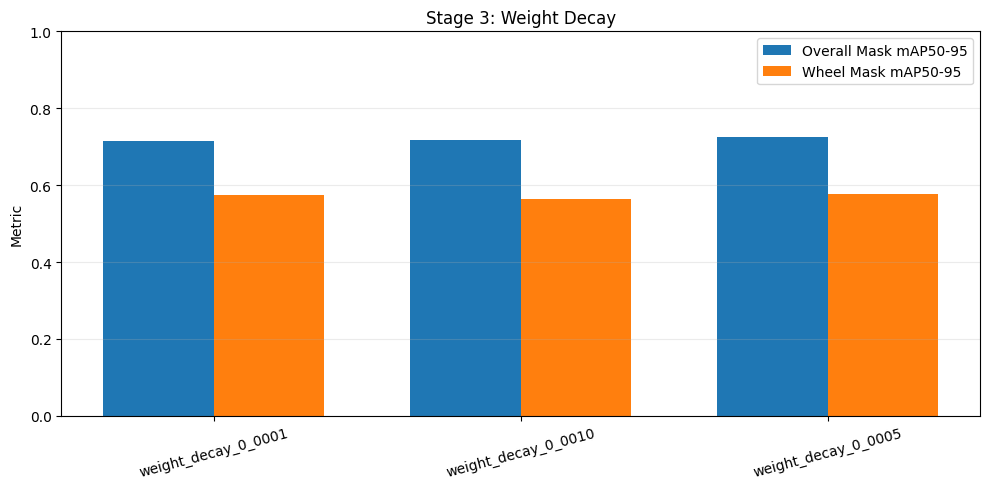

In [31]:
settings_after_lr = {
    **settings_after_optimizer,
    "lr0": BEST_LR,
}

weight_decay_results_df = run_trial_stage(
    stage_name="03_weight_decay",
    candidates=weight_decay_candidates,
    base_settings=settings_after_lr,
)

display(weight_decay_results_df[[
    "trial",
    "overall_mask_map50_95",
    "wheel_mask_precision",
    "wheel_mask_recall",
    "wheel_mask_map50_95",
]])

plot_stage_results(weight_decay_results_df, "Stage 3: Weight Decay")

In [32]:
weight_decay_winner, weight_decay_finalists = choose_stage_winner(
    weight_decay_results_df, tolerance=0.005
)

print("Candidates within 0.005 of best overall result:")

display(weight_decay_finalists[[
    "trial",
    "overall_mask_map50_95",
    "wheel_mask_map50_95",
    "wheel_mask_recall",
]])

BEST_WEIGHT_DECAY_TRIAL = weight_decay_winner["trial"]

BEST_WEIGHT_DECAY = next(
    candidate["overrides"]["weight_decay"]
    for candidate in weight_decay_candidates
    if candidate["name"] == BEST_WEIGHT_DECAY_TRIAL
)

print("Selected weight-decay trial:", BEST_WEIGHT_DECAY_TRIAL)
print("Selected weight_decay:", BEST_WEIGHT_DECAY)

Candidates within 0.005 of best overall result:


,trial,overall_mask_map50_95,wheel_mask_map50_95,wheel_mask_recall
0,weight_decay_0_0005,0.724411,0.5762,0.677712


Selected weight-decay trial: weight_decay_0_0005
Selected weight_decay: 0.0005


## 9. Stage 4 — Augmentation Strength

The selected optimizer, learning rate, and weight decay are fixed. Only the listed augmentation family changes. `baseline_aug` preserves Notebook 09's augmentation settings as the stage control.

In [33]:
augmentation_candidates = [
    {
        "name": "baseline_aug",
        "overrides": {
            "hsv_s": 0.30,
            "hsv_v": 0.30,
            "degrees": 10.0,
            "translate": 0.05,
            "scale": 0.15,
            "mosaic": 0.20,
        },
    },
    {
        "name": "light_aug",
        "overrides": {
            "hsv_s": 0.20,
            "hsv_v": 0.20,
            "degrees": 5.0,
            "translate": 0.03,
            "scale": 0.10,
            "mosaic": 0.10,
        },
    },
    {
        "name": "moderate_aug",
        "overrides": {
            "hsv_s": 0.40,
            "hsv_v": 0.40,
            "degrees": 12.0,
            "translate": 0.07,
            "scale": 0.25,
            "mosaic": 0.35,
        },
    },
]

display(pd.DataFrame([
    {"Trial": item["name"], **item["overrides"]}
    for item in augmentation_candidates
]))

,Trial,hsv_s,hsv_v,degrees,translate,scale,mosaic
0,baseline_aug,0.3,0.3,10.0,0.05,0.15,0.20
1,light_aug,0.2,0.2,5.0,0.03,0.10,0.10
2,moderate_aug,0.4,0.4,12.0,0.07,0.25,0.35


,trial,overall_mask_map50_95,wheel_mask_precision,wheel_mask_recall,wheel_mask_map50_95
0,moderate_aug,0.722788,0.818357,0.671007,0.607223
1,baseline_aug,0.724411,0.864322,0.677712,0.576200
2,light_aug,0.712410,0.805415,0.654255,0.563388


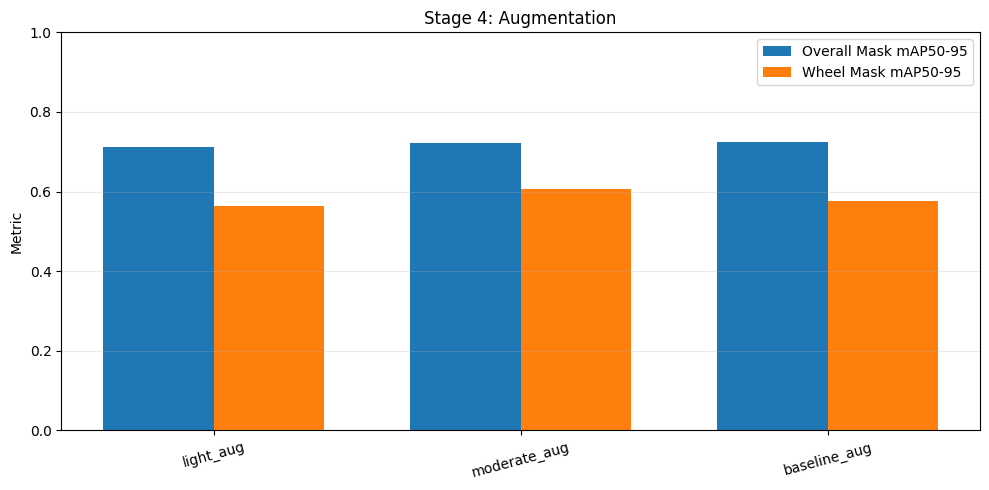

In [34]:
settings_after_weight_decay = {
    **settings_after_lr,
    "weight_decay": BEST_WEIGHT_DECAY,
}

aug_results_df = run_trial_stage(
    stage_name="04_augmentation",
    candidates=augmentation_candidates,
    base_settings=settings_after_weight_decay,
)

display(aug_results_df[[
    "trial",
    "overall_mask_map50_95",
    "wheel_mask_precision",
    "wheel_mask_recall",
    "wheel_mask_map50_95",
]])

plot_stage_results(aug_results_df, "Stage 4: Augmentation")

In [35]:
augmentation_winner, augmentation_finalists = choose_stage_winner(
    aug_results_df, tolerance=0.005
)

print("Candidates within 0.005 of best overall result:")

display(augmentation_finalists[[
    "trial",
    "overall_mask_map50_95",
    "wheel_mask_map50_95",
    "wheel_mask_precision",
    "wheel_mask_recall",
]])

BEST_AUG_TRIAL = augmentation_winner["trial"]

BEST_AUG_OVERRIDES = next(
    candidate["overrides"]
    for candidate in augmentation_candidates
    if candidate["name"] == BEST_AUG_TRIAL
)

print("Selected augmentation trial:", BEST_AUG_TRIAL)

display(pd.DataFrame(
    BEST_AUG_OVERRIDES.items(),
    columns=["Setting", "Value"],
))

Candidates within 0.005 of best overall result:


,trial,overall_mask_map50_95,wheel_mask_map50_95,wheel_mask_precision,wheel_mask_recall
0,moderate_aug,0.722788,0.607223,0.818357,0.671007
1,baseline_aug,0.724411,0.576200,0.864322,0.677712


Selected augmentation trial: moderate_aug


,Setting,Value
0,hsv_s,0.40
1,hsv_v,0.40
2,degrees,12.00
3,translate,0.07
4,scale,0.25
5,mosaic,0.35


## 10. Stage 5 — Learning-Rate Schedule

The selected learning rate and augmentation configuration are fixed. Only cosine scheduling changes.

In [36]:
schedule_candidates = [
    {"name": "linear_schedule", "overrides": {"cos_lr": False}},
    {"name": "cosine_schedule", "overrides": {"cos_lr": True}},
]

display(pd.DataFrame([
    {"Trial": item["name"], **item["overrides"]}
    for item in schedule_candidates
]))

,Trial,cos_lr
0,linear_schedule,False
1,cosine_schedule,True


,trial,overall_mask_map50_95,wheel_mask_precision,wheel_mask_recall,wheel_mask_map50_95
0,cosine_schedule,0.722931,0.831229,0.707339,0.627887
1,linear_schedule,0.722788,0.818357,0.671007,0.607223


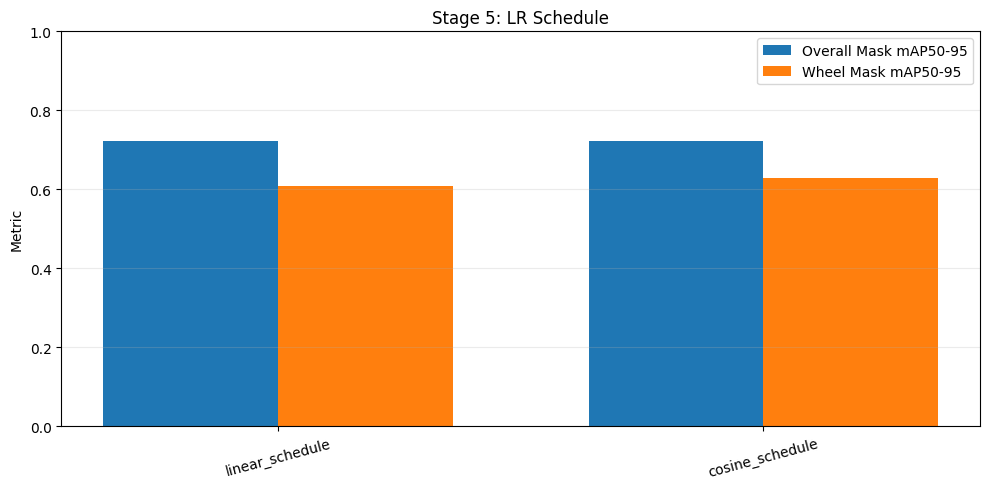

In [37]:
settings_after_augmentation = {
    **settings_after_weight_decay,
    **BEST_AUG_OVERRIDES,
}

schedule_results_df = run_trial_stage(
    stage_name="05_schedule",
    candidates=schedule_candidates,
    base_settings=settings_after_augmentation,
)

display(schedule_results_df[[
    "trial",
    "overall_mask_map50_95",
    "wheel_mask_precision",
    "wheel_mask_recall",
    "wheel_mask_map50_95",
]])

plot_stage_results(schedule_results_df, "Stage 5: LR Schedule")

In [38]:
schedule_winner, schedule_finalists = choose_stage_winner(
    schedule_results_df, tolerance=0.005
)

print("Candidates within 0.005 of best overall result:")

display(schedule_finalists[[
    "trial",
    "overall_mask_map50_95",
    "wheel_mask_map50_95",
    "wheel_mask_precision",
    "wheel_mask_recall",
]])

BEST_SCHEDULE_TRIAL = schedule_winner["trial"]

BEST_COS_LR = next(
    candidate["overrides"]["cos_lr"]
    for candidate in schedule_candidates
    if candidate["name"] == BEST_SCHEDULE_TRIAL
)

FINAL_HYPERPARAMETERS = {
    **settings_after_augmentation,
    "cos_lr": BEST_COS_LR,
}

print("Selected schedule:", BEST_SCHEDULE_TRIAL)
print("Selected cos_lr:", BEST_COS_LR)

Candidates within 0.005 of best overall result:


,trial,overall_mask_map50_95,wheel_mask_map50_95,wheel_mask_precision,wheel_mask_recall
0,cosine_schedule,0.722931,0.627887,0.831229,0.707339
1,linear_schedule,0.722788,0.607223,0.818357,0.671007


Selected schedule: cosine_schedule
Selected cos_lr: True


## 11. Final 50-Epoch Training

Review the five stage tables before running this section. If two trials are nearly tied, prefer the simpler configuration and confirm that wheel Recall did not materially decline.

In [39]:
FINAL_RUN_NAME = "carparts_yolo11n_manual_tuned_v2"

print("Final hyperparameters:")
display(pd.DataFrame(
    FINAL_HYPERPARAMETERS.items(),
    columns=["Setting", "Value"],
))

required_settings = {
    "optimizer": "AdamW",
    "lr0": 0.001,
    "weight_decay": 0.0005,
    "cos_lr": True,
}

for setting, expected_value in required_settings.items():
    actual_value = FINAL_HYPERPARAMETERS.get(setting)

    assert actual_value == expected_value, (
        f"{setting}: expected {expected_value}, got {actual_value}"
    )

print("Final configuration verified. Starting training...")

final_model = YOLO("yolo11n-seg.pt")

final_model.train(
    data=str(DATASET_YAML),
    epochs=50,
    patience=10,
    project=str(RUNS_DIR),
    name=FINAL_RUN_NAME,
    save=True,
    save_period=5,
    plots=True,
    verbose=True,
    exist_ok=True,
    **FINAL_HYPERPARAMETERS,
)

FINAL_TRAINING_DIR = Path(final_model.trainer.save_dir)
BEST_MODEL_PATH = FINAL_TRAINING_DIR / "weights" / "best.pt"

print("Final training directory:", FINAL_TRAINING_DIR)
print("Best model:", BEST_MODEL_PATH)
print("Best model exists:", BEST_MODEL_PATH.exists())

Final hyperparameters:


,Setting,Value
0,optimizer,AdamW
1,lrf,0.01
2,momentum,0.9
3,weight_decay,0.0005
4,cos_lr,True
5,hsv_h,0.01
6,hsv_s,0.4
7,hsv_v,0.4
8,degrees,12.0
9,translate,0.07


## 12. Final Validation and Baseline Comparison

In [41]:
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_CSV = FINAL_TRAINING_DIR / "results.csv"

history_df = pd.read_csv(RESULTS_CSV)
history_df.columns = history_df.columns.str.strip()

MASK_MAP_COLUMN = "metrics/mAP50-95(M)"

best_index = history_df[MASK_MAP_COLUMN].idxmax()
best_epoch = int(history_df.loc[best_index, "epoch"])
best_mask_map = history_df.loc[best_index, MASK_MAP_COLUMN]

last_mask_map = history_df[MASK_MAP_COLUMN].iloc[-1]
last_five_mean = history_df[MASK_MAP_COLUMN].tail(5).mean()
drop_from_best = best_mask_map - last_five_mean

print("Best epoch:", best_epoch)
print("Best validation Mask mAP50-95:", round(best_mask_map, 4))
print("Last epoch Mask mAP50-95:", round(last_mask_map, 4))
print("Last 5 epochs mean:", round(last_five_mean, 4))
print("Drop from best to last-5 mean:", round(drop_from_best, 4))

Best epoch: 38
Best validation Mask mAP50-95: 0.7413
Last epoch Mask mAP50-95: 0.733
Last 5 epochs mean: 0.7334
Drop from best to last-5 mean: 0.0079


In [43]:
best_model = YOLO(str(BEST_MODEL_PATH))
final_val = best_model.val(
    data=str(DATASET_YAML),
    split="val",
    imgsz=640,
    batch=8,
    device=0,
    workers=2,
    project=str(RUNS_DIR),
    name="manual_tuned_v2_validation",
    plots=True,
    exist_ok=True,
)

FINAL_VAL_DIR = Path(final_val.save_dir)
final_metrics = extract_validation_metrics(final_val, WHEEL_CLASS_ID)

with open(FINAL_VAL_DIR / "validation_metrics.json", "w") as file:
    json.dump(final_metrics, file, indent=4)

display(pd.DataFrame(
    final_metrics.items(), columns=["Metric", "Final validation"]
))

,Metric,Final validation
0,overall_mask_precision,0.867218
1,overall_mask_recall,0.902948
2,overall_mask_map50,0.931183
3,overall_mask_map50_95,0.740408
4,wheel_mask_precision,0.787341
5,wheel_mask_recall,0.750000
6,wheel_mask_map50,0.831842
7,wheel_mask_map50_95,0.602619


In [44]:
comparison_df = pd.DataFrame({
    "Metric": [
        "Overall Mask mAP50",
        "Overall Mask mAP50-95",
        "Wheel Mask Precision",
        "Wheel Mask Recall",
        "Wheel Mask mAP50",
        "Wheel Mask mAP50-95",
    ],
    "Notebook 09 baseline": [
        BASELINE_METRICS["overall_mask_map50"],
        BASELINE_METRICS["overall_mask_map50_95"],
        BASELINE_METRICS["wheel_mask_precision"],
        BASELINE_METRICS["wheel_mask_recall"],
        BASELINE_METRICS["wheel_mask_map50"],
        BASELINE_METRICS["wheel_mask_map50_95"],
    ],
    "Manually tuned": [
        final_metrics["overall_mask_map50"],
        final_metrics["overall_mask_map50_95"],
        final_metrics["wheel_mask_precision"],
        final_metrics["wheel_mask_recall"],
        final_metrics["wheel_mask_map50"],
        final_metrics["wheel_mask_map50_95"],
    ],
})

comparison_df["Delta"] = (
    comparison_df["Manually tuned"]
    - comparison_df["Notebook 09 baseline"]
)

display(comparison_df)
comparison_df.to_csv(
    FINAL_VAL_DIR / "baseline_vs_tuned.csv", index=False
)

,Metric,Notebook 09 baseline,Manually tuned,Delta
0,Overall Mask mAP50,0.935,0.931183,-0.003817
1,Overall Mask mAP50-95,0.737,0.740408,0.003408
2,Wheel Mask Precision,0.833,0.787341,-0.045659
3,Wheel Mask Recall,0.761,0.750000,-0.011000
4,Wheel Mask mAP50,0.878,0.831842,-0.046158
5,Wheel Mask mAP50-95,0.618,0.602619,-0.015381


## 13. Training Curves

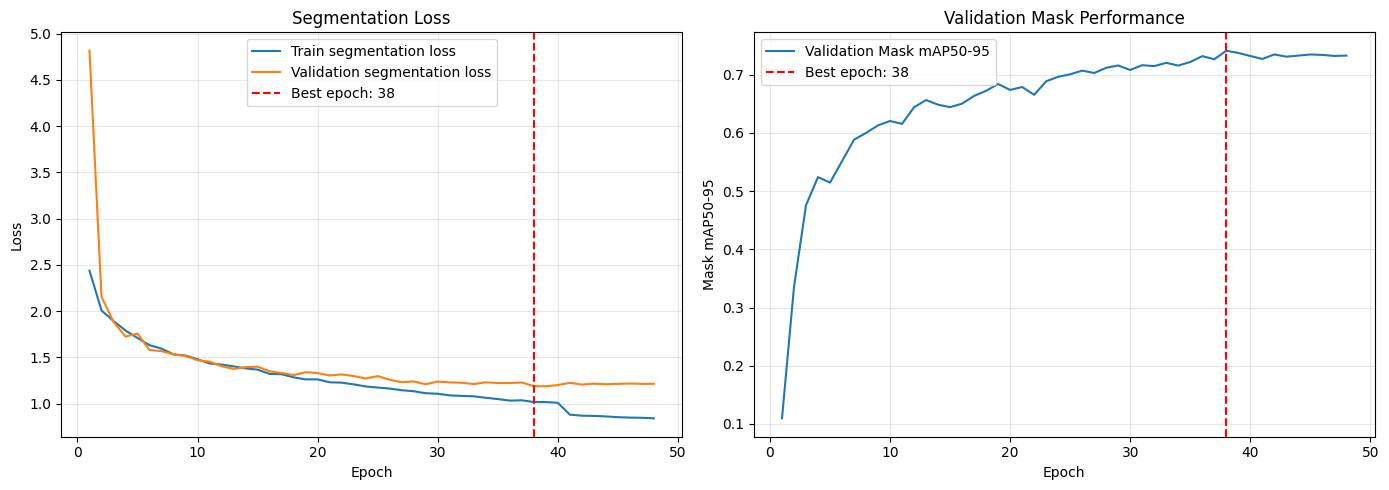

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(
    history_df["epoch"],
    history_df["train/seg_loss"],
    label="Train segmentation loss",
)

axes[0].plot(
    history_df["epoch"],
    history_df["val/seg_loss"],
    label="Validation segmentation loss",
)

axes[0].axvline(
    best_epoch,
    color="red",
    linestyle="--",
    label=f"Best epoch: {best_epoch}",
)

axes[0].set_title("Segmentation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(
    history_df["epoch"],
    history_df[MASK_MAP_COLUMN],
    label="Validation Mask mAP50-95",
)

axes[1].axvline(
    best_epoch,
    color="red",
    linestyle="--",
    label=f"Best epoch: {best_epoch}",
)

axes[1].set_title("Validation Mask Performance")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Mask mAP50-95")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 14. Export the Tuned Candidate Model

This section exports the best checkpoint from the tuned training run for reproducibility and comparison. It is the **tuned candidate model**, not the final selected model. Final model selection in the next section retains the wheel-fixed v3 baseline.

In [46]:
from pathlib import Path
from shutil import copy2
from IPython.display import FileLink, display

DOWNLOAD_MODEL_PATH = Path(
    "/kaggle/working/carparts_yolo11n_manual_tuned_v2_best.pt"
)

copy2(BEST_MODEL_PATH, DOWNLOAD_MODEL_PATH)

print("Source model:", BEST_MODEL_PATH)
print("Download file:", DOWNLOAD_MODEL_PATH)
print(
    "Size MB:",
    round(DOWNLOAD_MODEL_PATH.stat().st_size / 1_000_000, 2),
)

display(FileLink(str(DOWNLOAD_MODEL_PATH)))

Source model: /kaggle/working/qaddir-training-results/carparts_yolo11n_manual_tuned_v2/weights/best.pt
Download file: /kaggle/working/carparts_yolo11n_manual_tuned_v2_best.pt
Size MB: 6.01


/kaggle/working/carparts_yolo11n_manual_tuned_v2_best.pt

## 15. Model Selection and Locked Test Set

The manually tuned v2 model was compared with the Notebook 09 wheel-fixed v3 baseline on the same validation split.

The tuned model improved overall Mask mAP50-95 only marginally (+0.003408), within the predefined 0.005 practical tolerance, while reducing wheel Mask Precision, Recall, mAP50, and mAP50-95. The final selected model is therefore the baseline checkpoint `carparts_yolo11n_wheel_fixed_v3_best.pt`.

The test split remained locked during tuning and model selection. It was evaluated once only after selecting the final model.

In [47]:
MODEL_SELECTION_TOLERANCE = 0.005

baseline_validation = {
    "model": "wheel_fixed_v3_baseline",
    "overall_mask_map50_95": 0.737,
    "wheel_mask_map50_95": 0.618,
    "wheel_mask_recall": 0.761,
}

tuned_validation = {
    "model": "manual_tuned_v2",
    "overall_mask_map50_95": final_metrics["overall_mask_map50_95"],
    "wheel_mask_map50_95": final_metrics["wheel_mask_map50_95"],
    "wheel_mask_recall": final_metrics["wheel_mask_recall"],
}

model_comparison_df = pd.DataFrame([
    baseline_validation,
    tuned_validation,
])

display(model_comparison_df[[
    "model",
    "overall_mask_map50_95",
    "wheel_mask_map50_95",
]])

overall_difference = (
    tuned_validation["overall_mask_map50_95"]
    - baseline_validation["overall_mask_map50_95"]
)

selection_input_df = model_comparison_df.rename(
    columns={"model": "trial"}
)
selected_result, model_finalists = choose_stage_winner(
    selection_input_df, tolerance=MODEL_SELECTION_TOLERANCE
)

SELECTED_MODEL_NAME = selected_result["trial"]
SELECTED_MODEL_FILENAME = "carparts_yolo11n_wheel_fixed_v3_best.pt"
selection_reason = (
    "Overall results were within the 0.005 tolerance; "
    "wheel Mask mAP50-95 was used as the tie-breaker."
)

print("Overall difference:", round(overall_difference, 6))
print("Selected model:", SELECTED_MODEL_NAME)
print("Selected checkpoint:", SELECTED_MODEL_FILENAME)
print("Reason:", selection_reason)

,model,overall_mask_map50_95,wheel_mask_map50_95
0,wheel_fixed_v3_baseline,0.737000,0.618000
1,manual_tuned_v2,0.740408,0.602619


Overall difference: 0.003408
Selected model: wheel_fixed_v3_baseline
Selected checkpoint: carparts_yolo11n_wheel_fixed_v3_best.pt
Reason: Overall results were within the 0.005 tolerance; wheel Mask mAP50-95 was used as the tie-breaker.


## 16. Final Test Evaluation

The wheel-fixed v3 baseline was selected using validation results before opening the test split.

The test split remained locked during tuning and model selection. It was evaluated once only after selecting the final model.

These test results estimate final generalization performance and were not used for further tuning or model selection.

In [48]:
from pathlib import Path
from ultralytics import YOLO

baseline_candidates = list(
    Path("/kaggle/input").rglob(
        "carparts_yolo11n_wheel_fixed_v3_best.pt"
    )
)

if len(baseline_candidates) != 1:
    raise FileNotFoundError(
        "Expected exactly one baseline model, "
        f"but found {len(baseline_candidates)}: "
        f"{baseline_candidates}"
    )

BASELINE_MODEL_PATH = baseline_candidates[0]
baseline_model = YOLO(str(BASELINE_MODEL_PATH))

print("Selected baseline model:", BASELINE_MODEL_PATH)

Selected baseline model: /kaggle/input/models/haifafd/carparts-yolo11n-wheel-fixed-v3/pytorch/-/1/carparts_yolo11n_wheel_fixed_v3_best.pt


In [49]:
final_test = baseline_model.val(
    data=str(DATASET_YAML),
    split="test",
    imgsz=640,
    batch=8,
    device=0,
    workers=2,
    project=str(RUNS_DIR),
    name="wheel_fixed_v3_final_test",
    plots=True,
    exist_ok=True,
)

final_test_metrics = extract_validation_metrics(
    final_test,
    WHEEL_CLASS_ID,
)

display(pd.DataFrame(
    final_test_metrics.items(),
    columns=["Metric", "Final test"],
))

FINAL_TEST_DIR = Path(final_test.save_dir)

print("Final test results:", FINAL_TEST_DIR)

# Reached only after the final test evaluation above succeeds.
TEST_EVALUATED_IN_THIS_NOTEBOOK = True

,Metric,Final test
0,overall_mask_precision,0.837912
1,overall_mask_recall,0.896619
2,overall_mask_map50,0.905708
3,overall_mask_map50_95,0.707066
4,wheel_mask_precision,0.743791
5,wheel_mask_recall,0.812500
6,wheel_mask_map50,0.845397
7,wheel_mask_map50_95,0.611225


Final test results: /kaggle/working/qaddir-training-results/wheel_fixed_v3_final_test


### Final Test Conclusion

The final selected model is the baseline checkpoint `carparts_yolo11n_wheel_fixed_v3_best.pt`. The tuned model improved validation overall Mask mAP50-95 only marginally (+0.003408), but reduced wheel performance, so the baseline remained the stronger practical choice.

The test split remained locked during tuning and model selection. It was evaluated once only after selecting the final model.

| Metric | Final test |
|---|---:|
| Overall Mask Precision | 0.837912 |
| Overall Mask Recall | 0.896619 |
| Overall Mask mAP50 | 0.905708 |
| Overall Mask mAP50-95 | 0.707066 |
| Wheel Mask Precision | 0.743791 |
| Wheel Mask Recall | 0.812500 |
| Wheel Mask mAP50 | 0.845397 |
| Wheel Mask mAP50-95 | 0.611225 |

The results indicate acceptable generalization for a proof-of-concept instance-segmentation model. Remaining limitations include class imbalance, limited instances for rare classes, and known inconsistencies in wheel annotations. No additional tuning decisions were made using the test results.